<div style="padding:20px;color:white;margin:0;font-size:300%;text-align:center;display:fill;border-radius:80px;background-color:purple;overflow:hidden;font-weight:800">Digital Literacy Education
</div>

In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## <b><div style='padding:15px;background-color:purple;color:white;border-radius:40px;font-size:110%;text-align: center'>1  |  About Dataset</div></b>

**This dataset is designed to support research and development in improving digital literacy education in rural areas, with a focus on rural revitalization. It includes comprehensive learner interaction data, demographic attributes, and post-training outcomes, making it suitable for building adaptive and personalized learning systems.**

**Key features of this dataset include:**

* Demographics: Information on age, gender, education level, employment status, household income, and location type.
* Pre-Training Scores: Baseline scores for basic computer knowledge, internet usage, and mobile literacy.
* Post-Training Progress: Scores achieved after training to track the impact of education modules.
* Engagement Metrics: Data on session counts, modules completed, average time spent per module, and quiz performance.
* Behavioral Insights: Engagement levels, adaptability scores, and learner feedback ratings.
* Outcome Measures: Overall digital literacy scores, skill application data, and employment impact information.


## <b><div style='padding:15px;background-color:purple;color:white;border-radius:40px;font-size:110%;text-align: center'>2  |  Libraries</div></b>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as pyo 
import plotly.io as pio
from plotly.offline import iplot

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


import warnings
warnings.filterwarnings('ignore')

## <b><div style='padding:15px;background-color:purple;color:white;border-radius:40px;font-size:110%;text-align: center'>3  |  Dataset</div></b>

In [7]:
df = pd.read_csv('digital_literacy_dataset_4000.csv')

In [9]:
df.head()

,User_ID,Age,Gender,Education_Level,Employment_Status,Household_Income,Location_Type,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,...,Modules_Completed,Average_Time_Per_Module,Quiz_Performance,Session_Count,Engagement_Level,Adaptability_Score,Feedback_Rating,Skill_Application,Employment_Impact,Overall_Literacy_Score
0,U0001,23,Female,High School,Employed,High,Semi-Rural,5,22,31,...,7,5.75,68,48,Medium,90,1,52,Yes,55.30
1,U0002,64,Female,High School,Unemployed,Low,Urban,40,18,27,...,10,11.25,62,41,Low,91,2,79,No,68.95
2,U0003,19,Male,Primary,Other,Low,Rural,11,8,12,...,4,20.25,52,35,Low,52,4,50,Yes,60.27
3,U0004,38,Female,Postgraduate,Other,Low,Urban,0,36,41,...,14,7.58,80,38,Medium,79,2,52,Yes,56.32
4,U0005,30,Female,High School,Student,Medium,Semi-Rural,6,1,11,...,12,18.08,83,31,Low,52,1,81,No,77.32


## <b><div style='padding:15px;background-color:purple;color:white;border-radius:40px;font-size:110%;text-align: center'>4  |  Inspecting Dataframe Structure</div></b>

In [5]:
# Deleting unnecessary columns
df.drop(["User_ID"],
         axis=1, inplace=True)

In [6]:
# Cleaning up column names
df.columns = df.columns.str.replace(" ", "_")

In [7]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (1000, 22)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Age,int64,0,0.000,0,47,1000,18.0,64.0,40.864,13.573568,43,60,47
Gender,object,0,0.000,0,3,1000,NaN,NaN,NaN,NaN,Male,Female,Female
Education_Level,object,212,0.212,0,3,788,NaN,NaN,NaN,NaN,Primary,High School,Primary
Employment_Status,object,0,0.000,0,5,1000,NaN,NaN,NaN,NaN,Student,Farmer,Farmer
Household_Income,object,0,0.000,0,3,1000,NaN,NaN,NaN,NaN,Medium,Low,Low
Location_Type,object,0,0.000,0,2,1000,NaN,NaN,NaN,NaN,Semi-Rural,Rural,Semi-Rural
Basic_Computer_Knowledge_Score,int64,0,0.000,0,51,1000,0.0,50.0,24.97,14.838439,25,22,14
Internet_Usage_Score,int64,0,0.000,0,51,1000,0.0,50.0,24.822,15.045088,1,14,31
Mobile_Literacy_Score,int64,0,0.000,0,51,1000,0.0,50.0,25.728,15.002036,33,35,14
Post_Training_Basic_Computer_Knowledge_Score,int64,0,0.000,0,77,1000,21.0,98.0,60.141,17.238628,54,52,46


<div class="alert alert-block alert-info" style="background-color:#F0EEED;color:purple;border-color:black;width:80%;margin: auto;text-align: center;"><b>Insight: </b>We have Missing values ​​in the Education Level column, but we will not delete this data.</div>

## <b><div style='padding:15px;background-color:purple;color:white;border-radius:40px;font-size:110%;text-align: center'>5  |  Exploratory Data Analysis - EDA</div></b>

In [8]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    
    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    del cat_cols[1] 
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 1000
Variables: 22
cat_cols: 7
num_cols: 14
cat_but_car: 0
num_but_cat: 1


In [9]:
cat_cols, num_cols, cat_but_car

(['Gender',
  'Employment_Status',
  'Household_Income',
  'Location_Type',
  'Engagement_Level',
  'Employment_Impact',
  'Feedback_Rating'],
 ['Age',
  'Basic_Computer_Knowledge_Score',
  'Internet_Usage_Score',
  'Mobile_Literacy_Score',
  'Post_Training_Basic_Computer_Knowledge_Score',
  'Post_Training_Internet_Usage_Score',
  'Post_Training_Mobile_Literacy_Score',
  'Modules_Completed',
  'Average_Time_Per_Module',
  'Quiz_Performance',
  'Session_Count',
  'Adaptability_Score',
  'Skill_Application',
  'Overall_Literacy_Score'],
 [])

### <b><span style='color:#DEB078'>5.1 |</span><span style='color:purple'> Categorical Columns</span></b>  

        Gender  Ratio
Gender               
Female     465   46.5
Male       446   44.6
Other       89    8.9


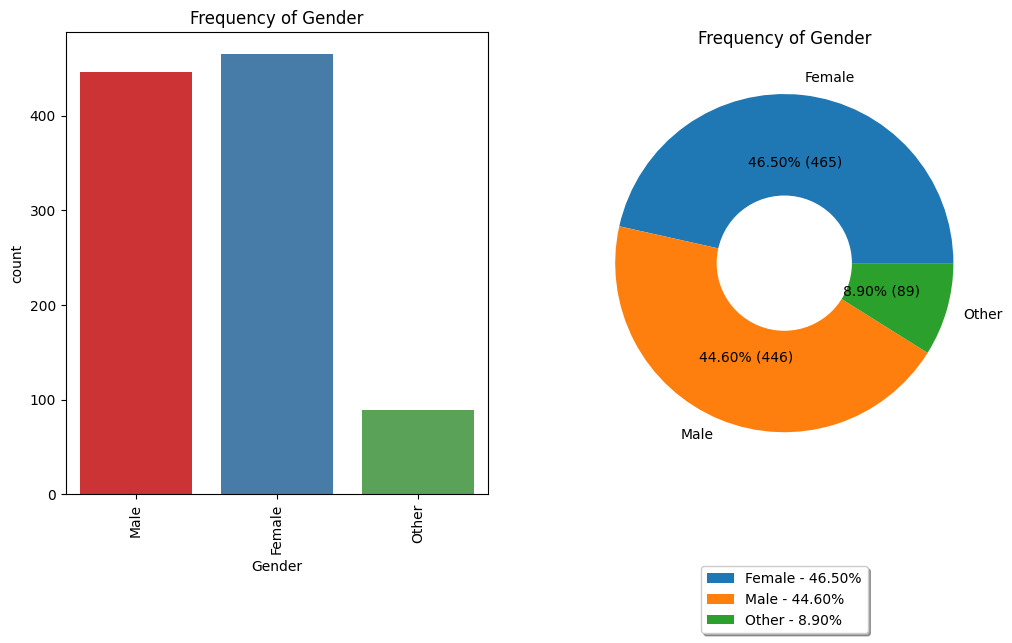

                   Employment_Status  Ratio
Employment_Status                          
Unemployed                       245   24.5
Self-Employed                    199   19.9
Farmer                           194   19.4
Other                            186   18.6
Student                          176   17.6


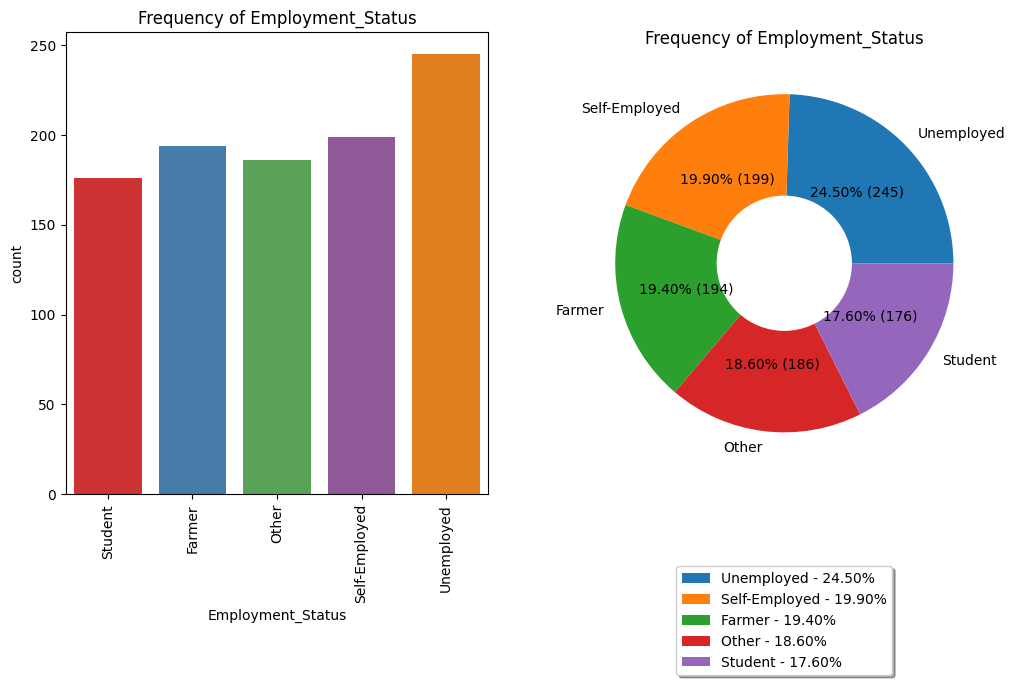

                  Household_Income  Ratio
Household_Income                         
Low                            595   59.5
Medium                         283   28.3
High                           122   12.2


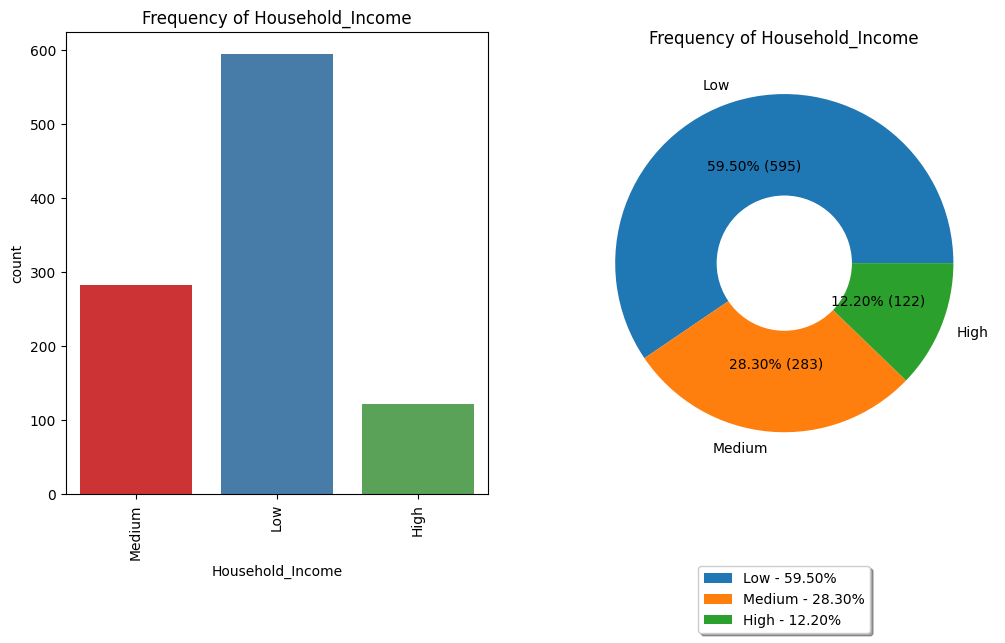

               Location_Type  Ratio
Location_Type                      
Rural                    702   70.2
Semi-Rural               298   29.8


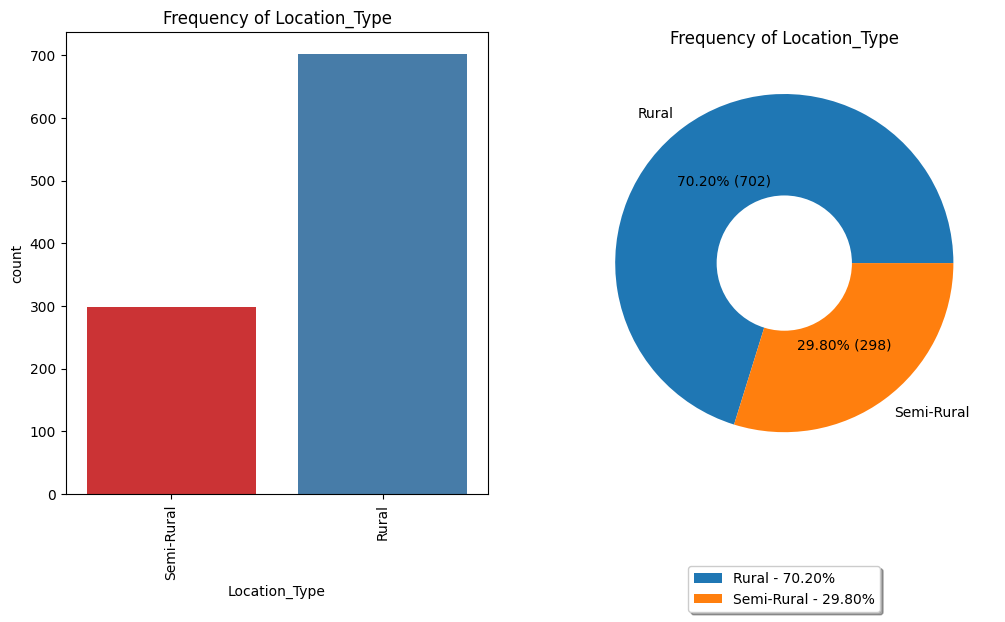

                  Engagement_Level  Ratio
Engagement_Level                         
Medium                         474   47.4
Low                            327   32.7
High                           199   19.9


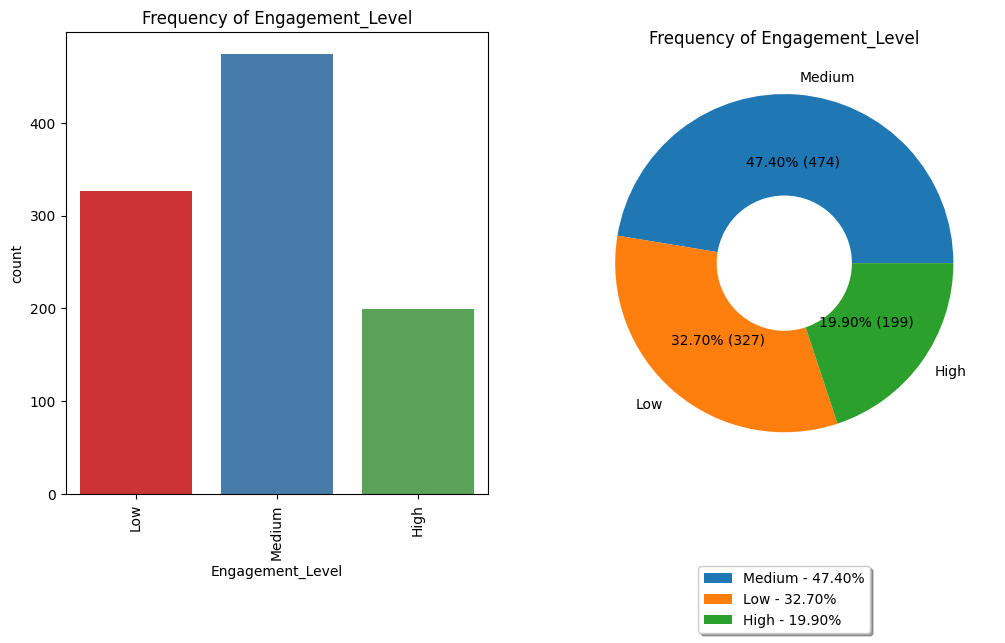

                   Employment_Impact  Ratio
Employment_Impact                          
No                               705   70.5
Yes                              295   29.5


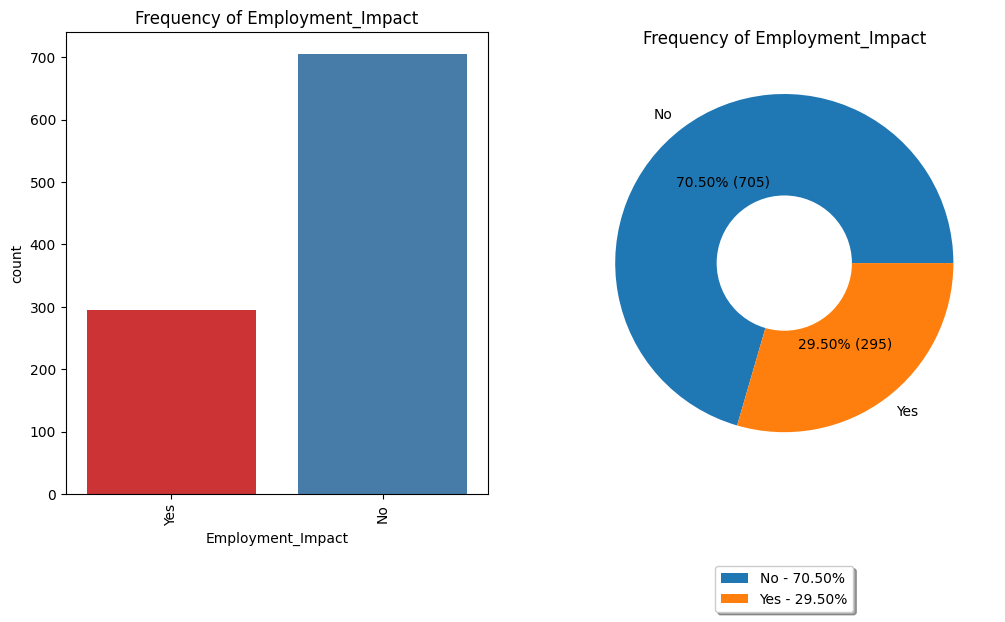

                 Feedback_Rating  Ratio
Feedback_Rating                        
4                            210   21.0
1                            200   20.0
3                            199   19.9
2                            198   19.8
5                            193   19.3


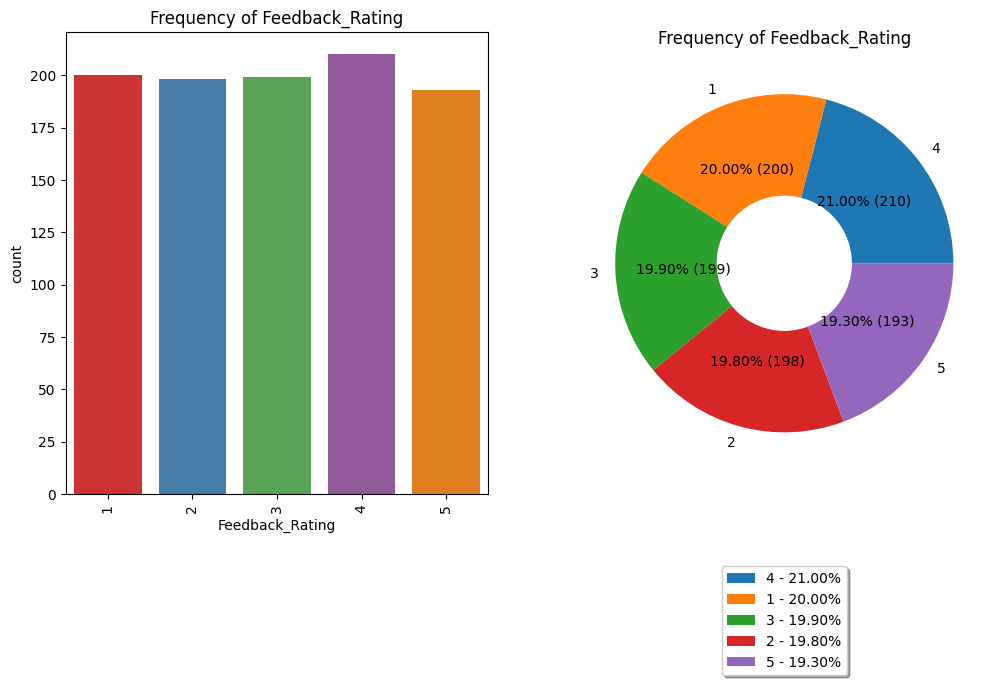

In [10]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))

    if plot:
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.countplot(x=dataframe[col_name], data=dataframe, palette = "Set1")
        plt.title("Frequency of " + col_name)
        plt.xticks(rotation=90)

        plt.subplot(1, 2, 2)
        values = dataframe[col_name].value_counts()
        plt.pie(x=values, labels=values.index, autopct=lambda p: '{:.2f}% ({:.0f})'.format(p, p/100 * sum(values)))
        hole = plt.Circle((0, 0), 0.40, facecolor='white')
        plt.gcf().gca().add_artist(hole)        
        plt.title("Frequency of " + col_name)
        plt.legend(labels=['{} - {:.2f}%'.format(index, value/sum(values)*100) for index, value in zip(values.index, values)],
                   loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=1)
        plt.show(block=True)

for col in cat_cols:
    cat_summary(df, col, True)

### <b><span style='color:#DEB078'>5.2 |</span><span style='color:purple'> Numerical Columns</span></b>

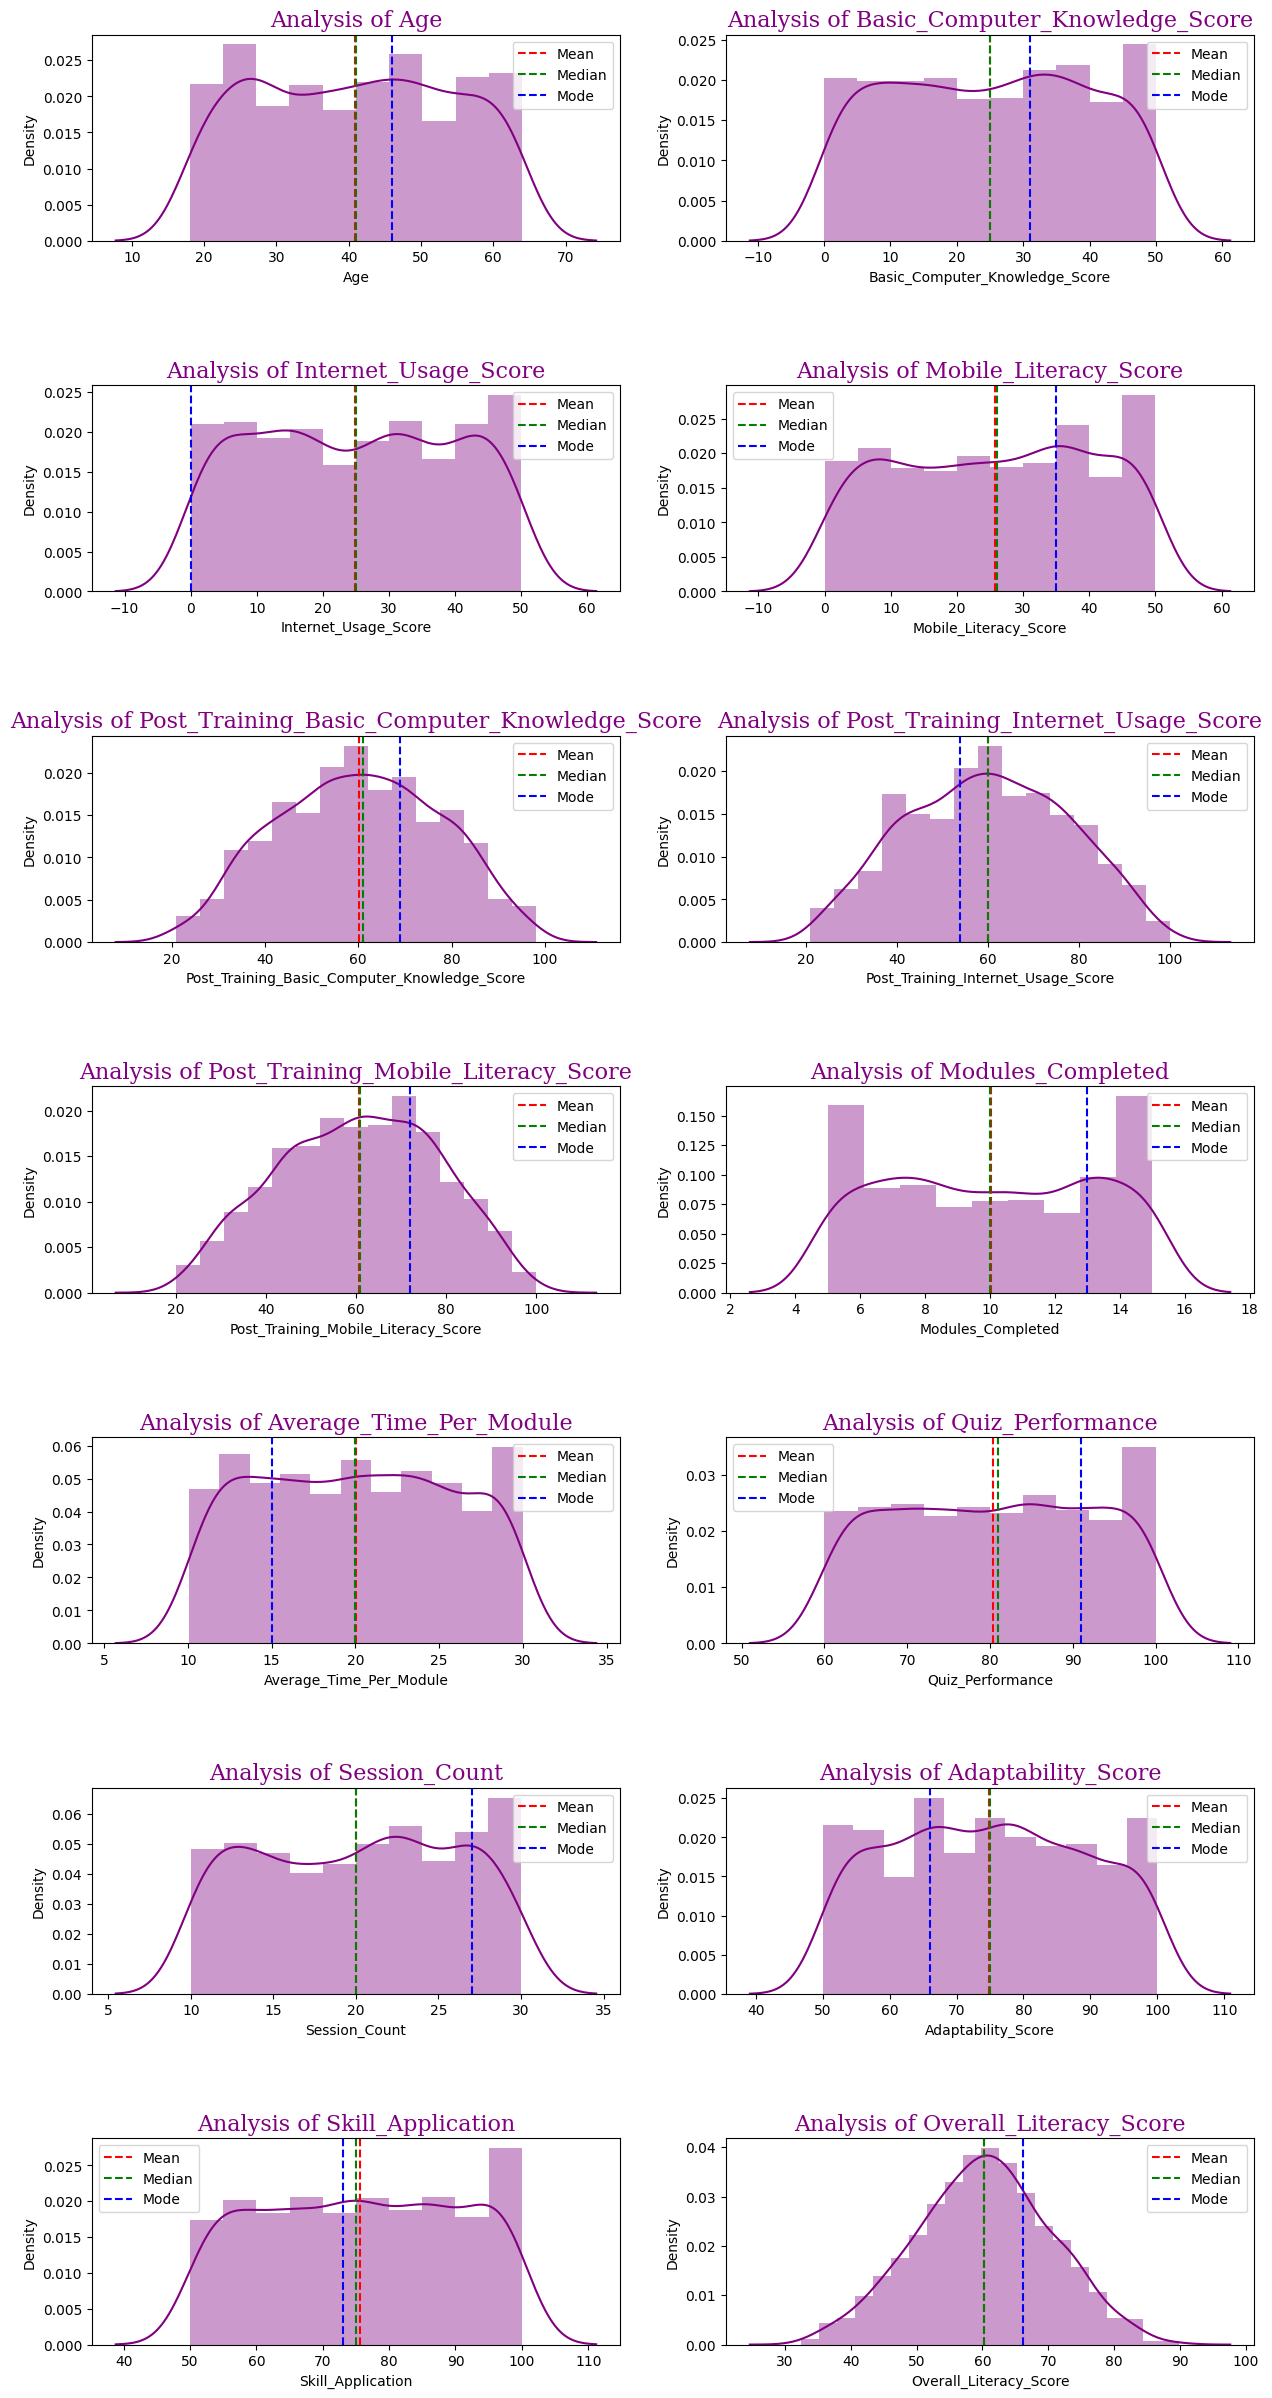

In [11]:
def generate_distribution_plot(df, num_cols):
    # create copy of dataframe
    data = df[num_cols].copy()
    # Create subplots 
    fig, axes = plt.subplots(nrows=len(data.columns)//2, ncols=2,figsize=(15,30))
    fig.subplots_adjust(hspace=0.7)
    
    # set fontdict
    font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 16,
        }
    
    # Generate distplot
    for ax, feature in zip(axes.flatten(), data.columns):
        feature_mean = data[feature].mean()
        feature_median = data[feature].median()
        feature_mode = data[feature].mode().values[0]
        sns.distplot(data[feature],ax=ax, color = 'purple')
        ax.set_title(f'Analysis of {feature}', fontdict=font, color = 'purple')
        ax.axvline(feature_mean, color='r', linestyle='--', label="Mean")
        ax.axvline(feature_median, color='g', linestyle='--', label="Median")
        ax.axvline(feature_mode, color='b', linestyle='--', label="Mode")
        ax.legend()
    plt.show()
    
generate_distribution_plot(df, num_cols)

### <b><span style='color:#DEB078'>5.3 |</span><span style='color:purple'> Heatmap of means for numerical features grouped by a categorical variable</span></b>

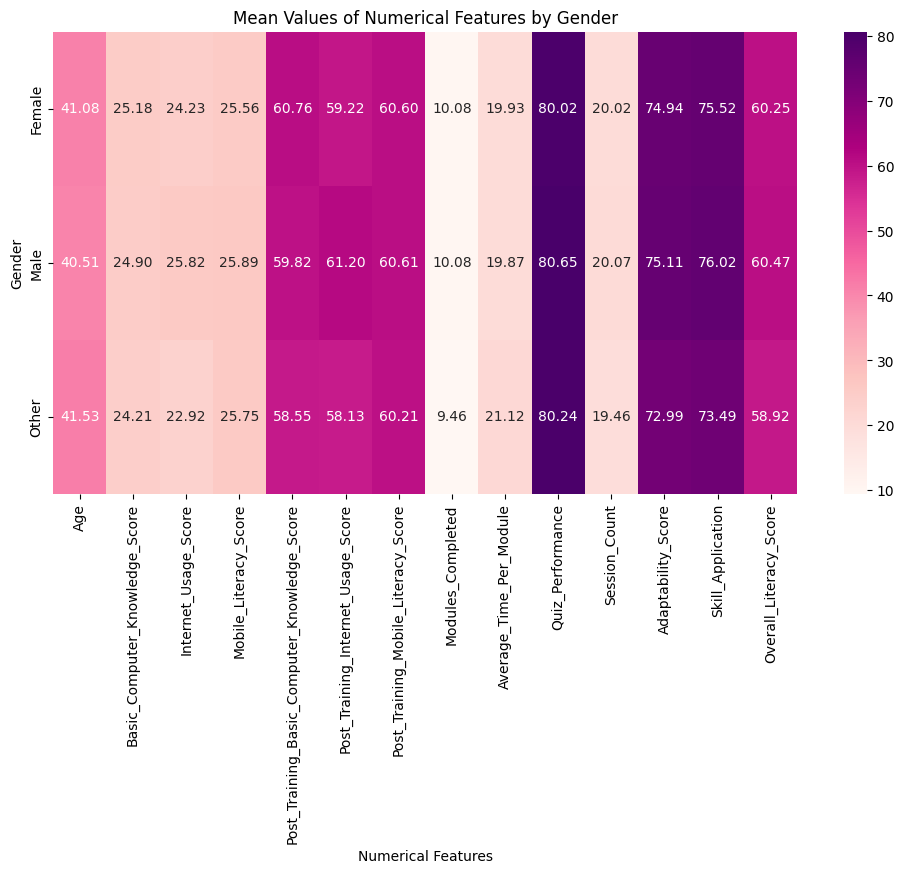

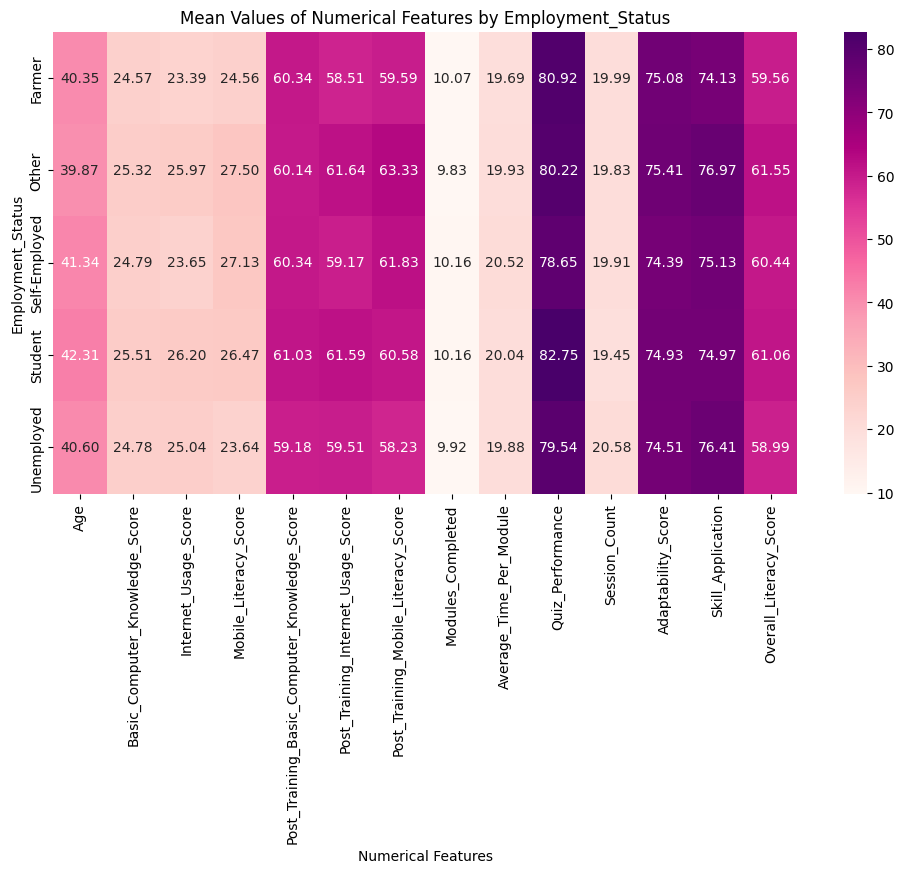

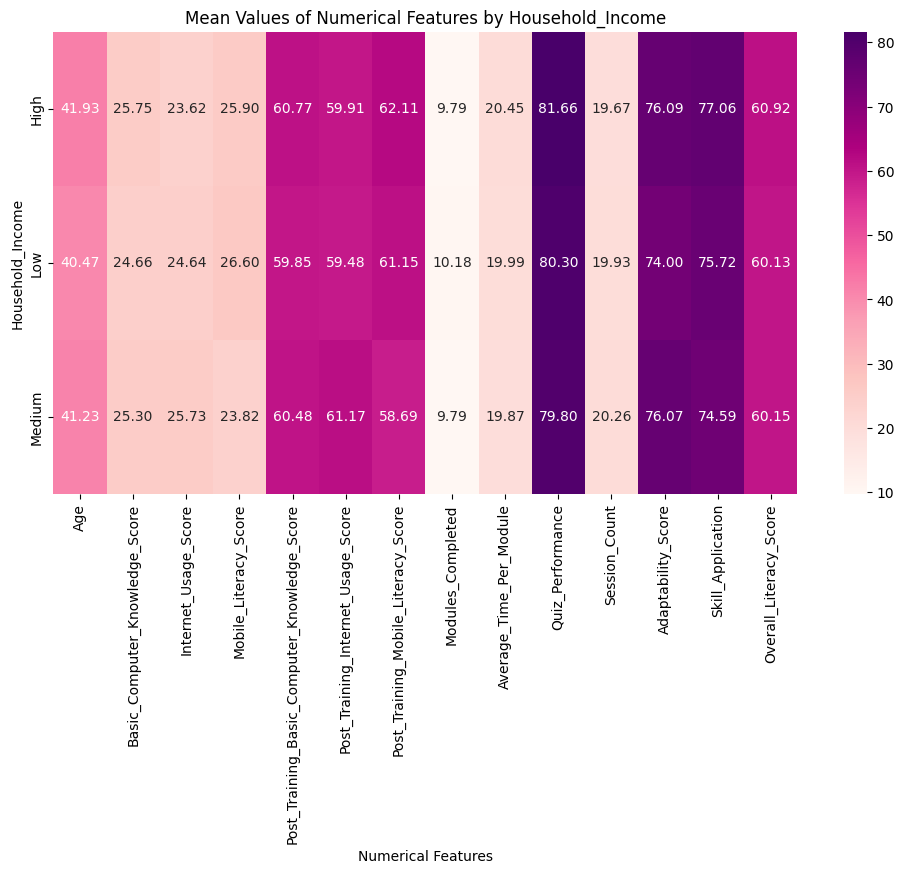

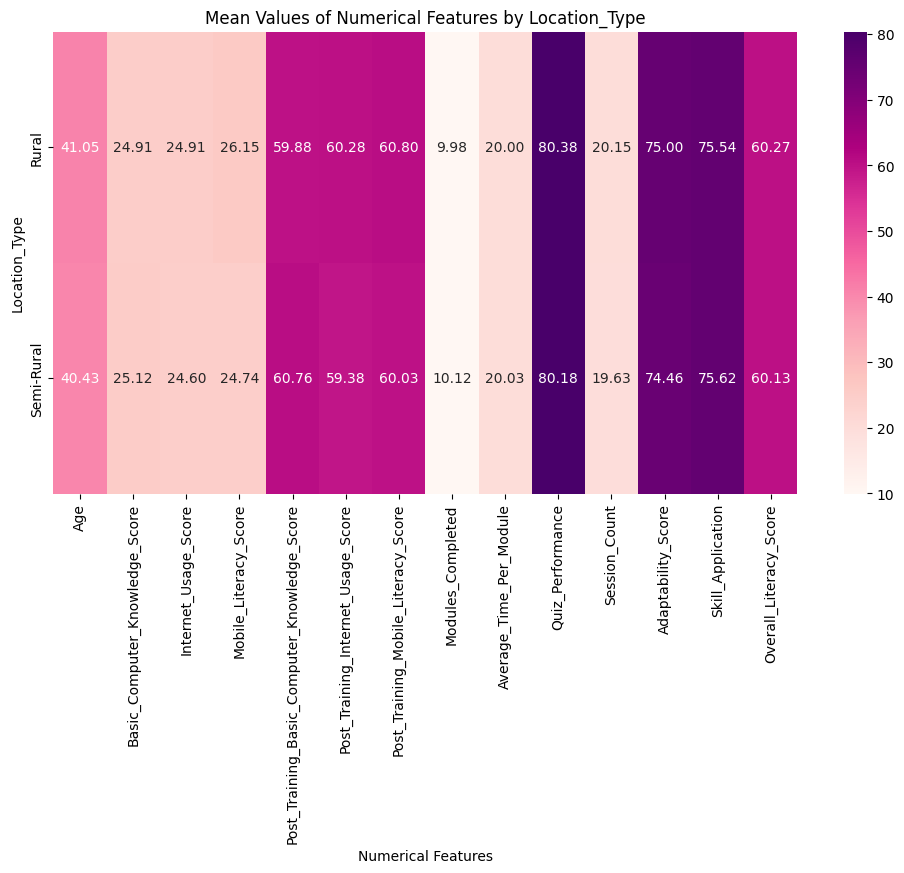

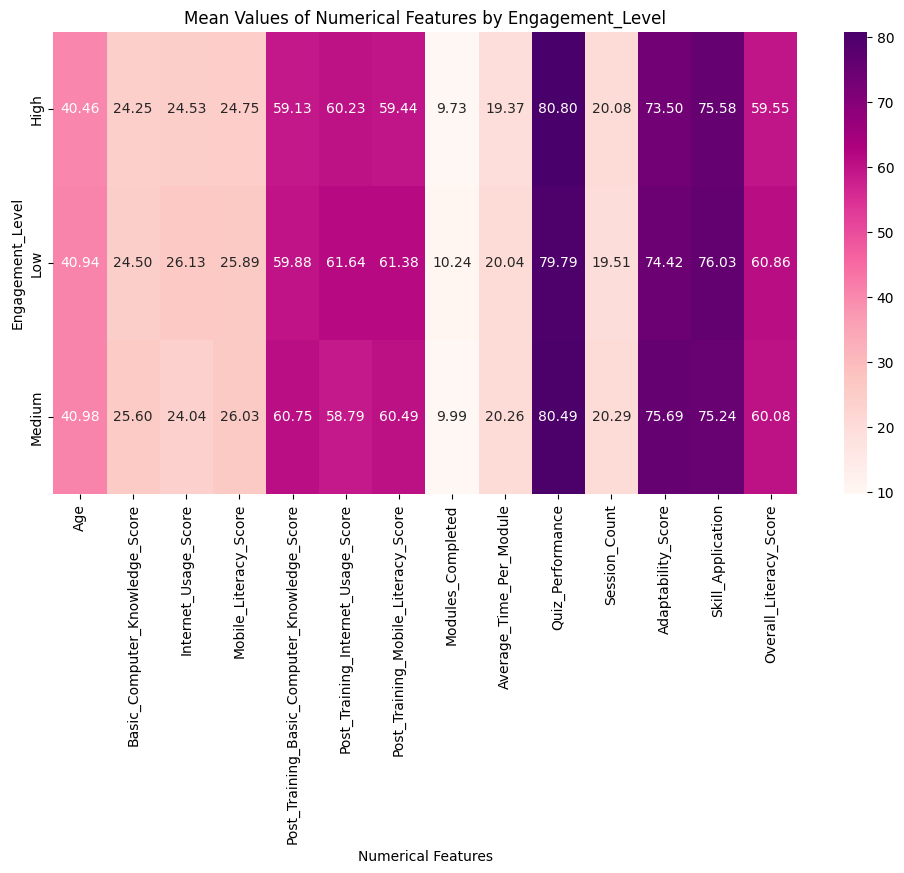

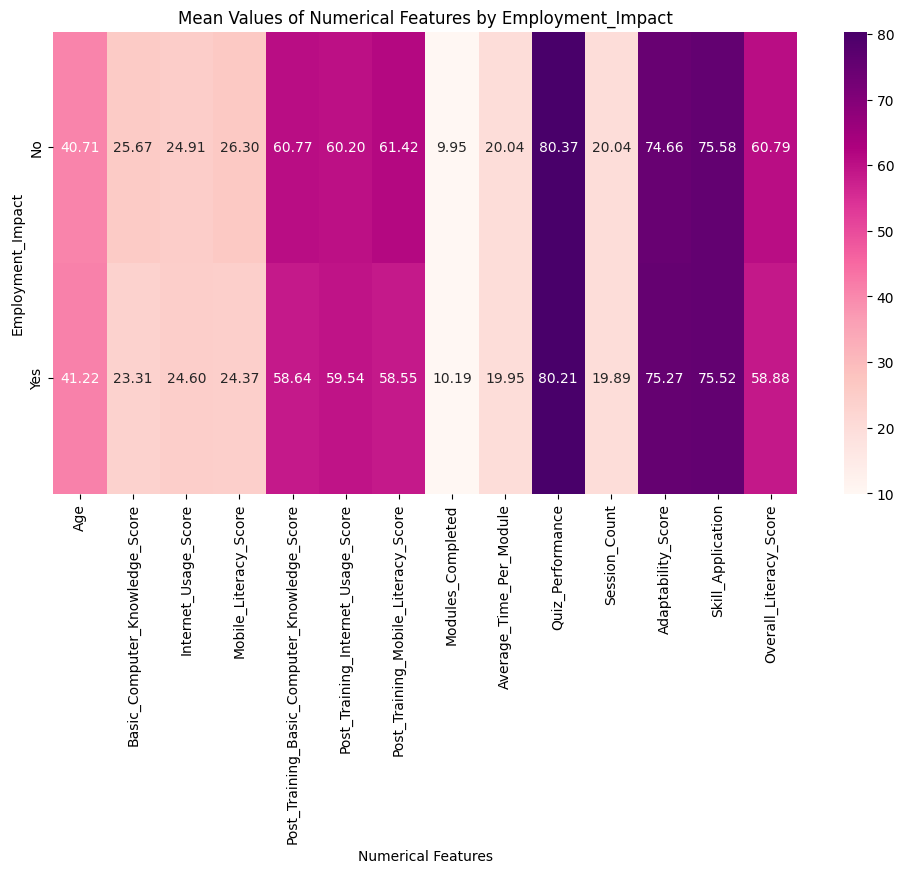

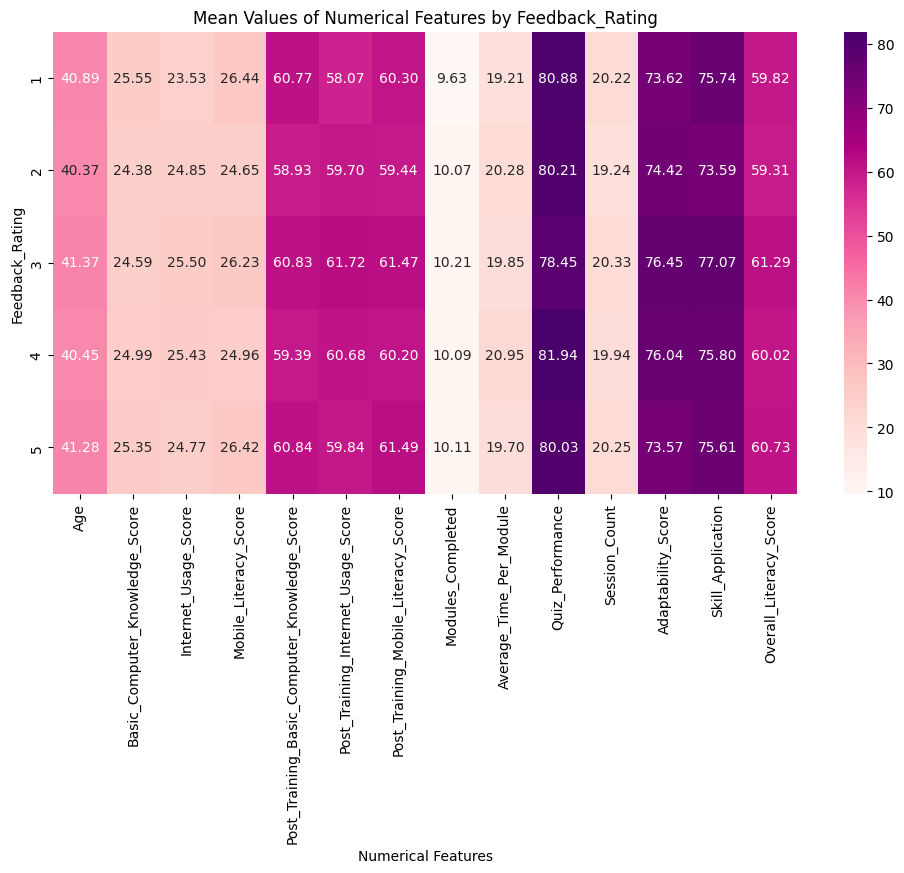

In [12]:
# Heatmap of means for numerical features grouped by a categorical variable
for cols in cat_cols:
    grouped_data = df.groupby(cols)[num_cols].mean()
    plt.figure(figsize=(12, 6))
    sns.heatmap(grouped_data, annot=True, fmt=".2f", cmap='RdPu')
    plt.title(f'Mean Values of Numerical Features by {cols}')
    plt.ylabel(cols)
    plt.xlabel('Numerical Features')
    plt.show()

### <b><span style='color:#DEB078'>5.4 |</span><span style='color:purple'> Target Column - Overall_Literacy_Score</span></b>

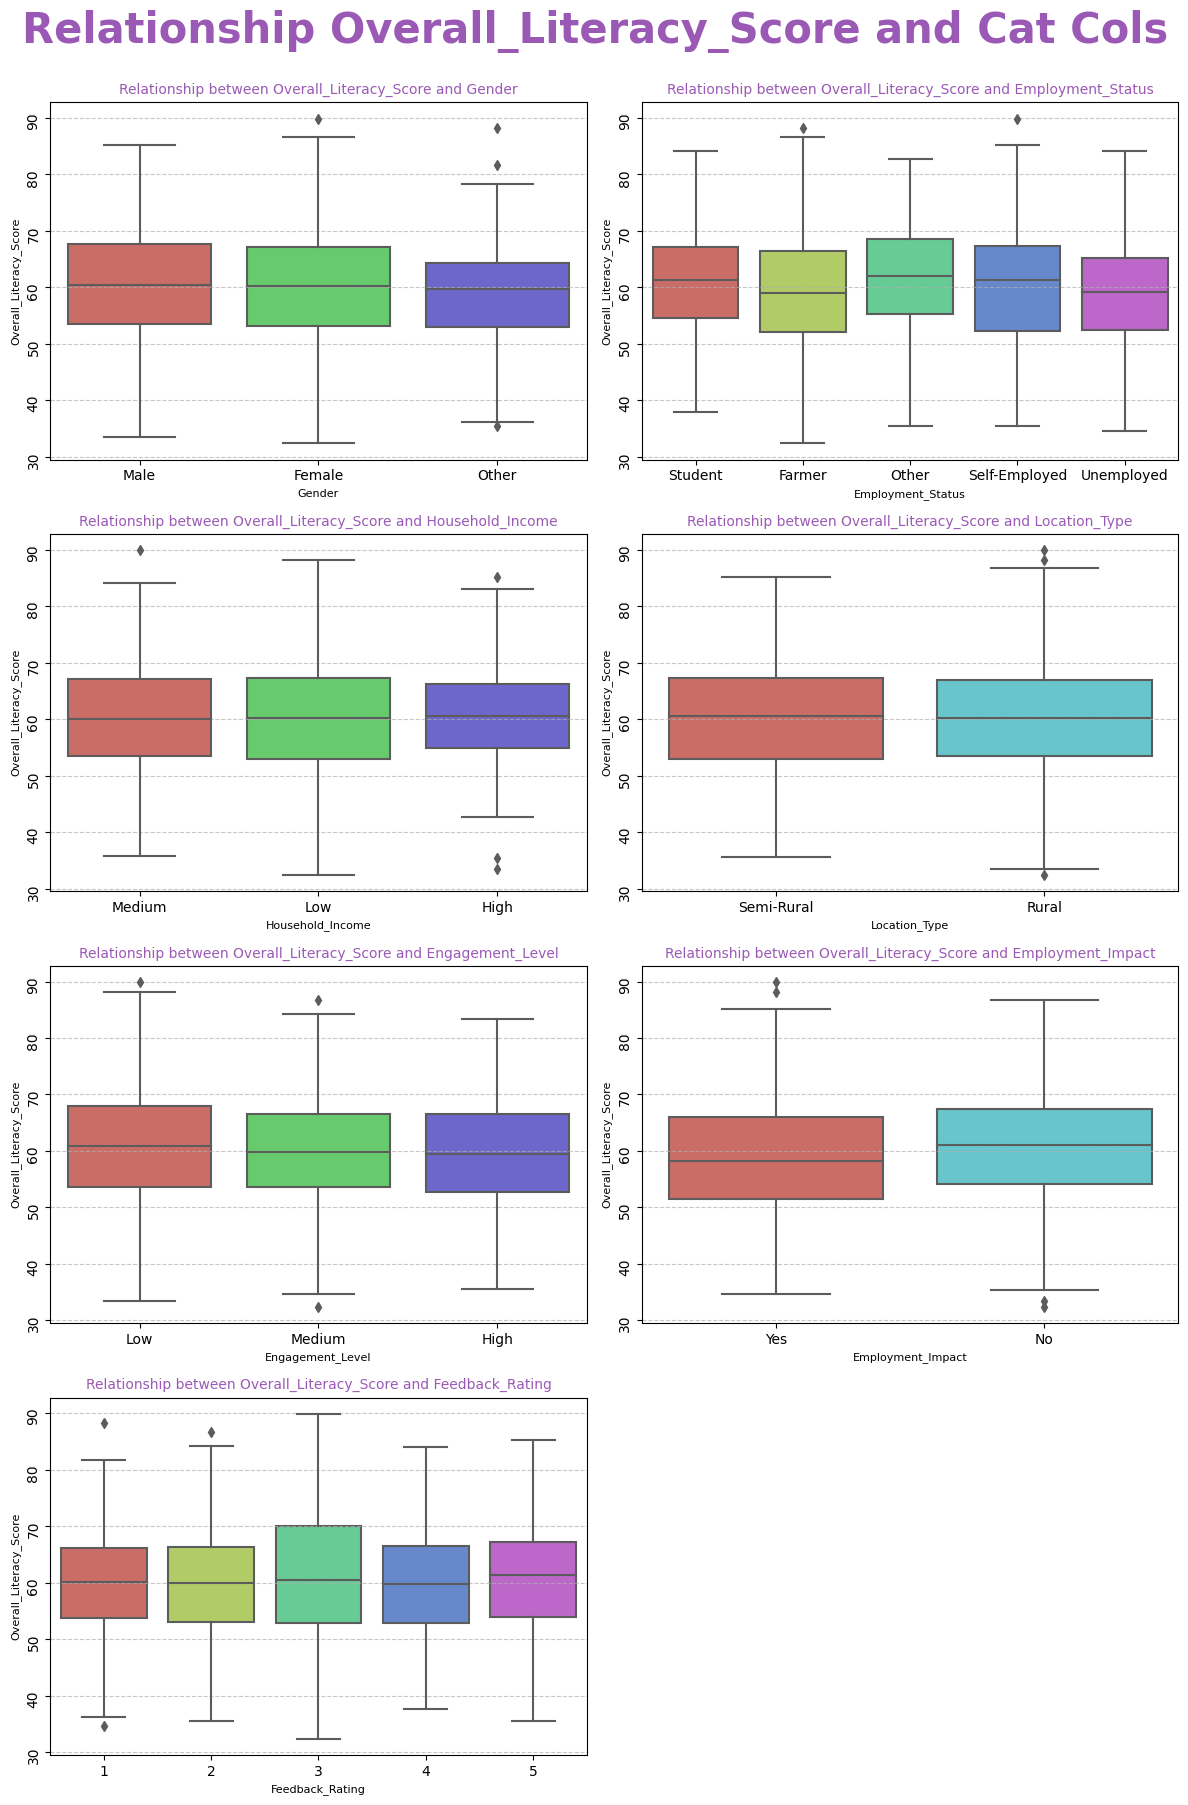

In [13]:
# Target Column
plt.figure(figsize=(12, 18))
plt.suptitle('Relationship Overall_Literacy_Score and Cat Cols', fontsize=30, fontweight='bold', y=1.0, color = '#9b59b6') 

for i, col in enumerate(cat_cols):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x=df[col], y=df['Overall_Literacy_Score'], palette='hls')
    plt.title(f'Relationship between Overall_Literacy_Score and {col}', fontsize=10, color = '#9b59b6')
    plt.xlabel(col, fontsize = 8)
    plt.yticks(rotation=90, fontsize = 10)
    plt.ylabel('Overall_Literacy_Score', fontsize = 8)
    plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()  
plt.show()

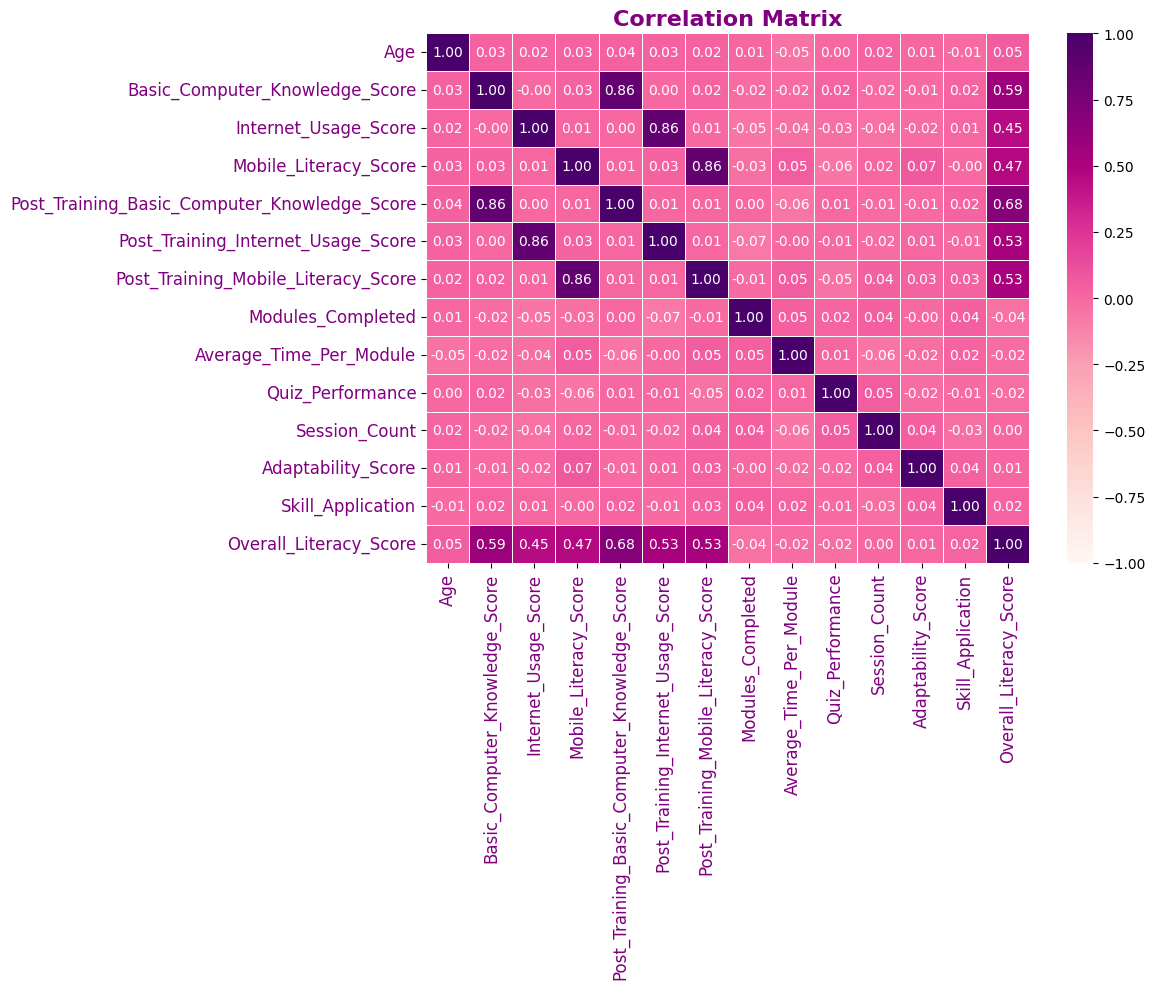

In [14]:
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='RdPu', fmt='.2f', cbar=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=16, fontweight='bold', color='purple')
plt.xticks(fontsize=12, color='purple')
plt.yticks(fontsize=12, color='purple')
plt.tight_layout()
plt.show()

## <b><div style='padding:15px;background-color:purple;color:white;border-radius:40px;font-size:110%;text-align: center'>6  |  Machine Learning</div></b>

In [15]:
# Prepare data for modeling
X = df[['Age', 'Gender', 'Education_Level', 'Employment_Status',
       'Household_Income', 'Location_Type', 'Basic_Computer_Knowledge_Score',
       'Internet_Usage_Score', 'Mobile_Literacy_Score',
       'Post_Training_Basic_Computer_Knowledge_Score',
       'Post_Training_Internet_Usage_Score',
       'Post_Training_Mobile_Literacy_Score', 'Modules_Completed',
       'Average_Time_Per_Module', 'Quiz_Performance', 'Session_Count',
       'Engagement_Level', 'Adaptability_Score', 'Feedback_Rating',
       'Skill_Application', 'Employment_Impact']]
X = pd.get_dummies(X, drop_first=False) 

# Normalize numerical features
numerical_features = ['Post_Training_Basic_Computer_Knowledge_Score', 'Internet_Usage_Score',
        'Mobile_Literacy_Score', 'Post_Training_Basic_Computer_Knowledge_Score',
        'Post_Training_Internet_Usage_Score']
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Encode categorical features
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
       ('cat', categorical_transformer, categorical_features)
    ])

# Apply transformations
X = preprocessor.fit_transform(X)

In [16]:
# Prepare data for modeling
y = df['Overall_Literacy_Score']  

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
rf = RandomForestRegressor()

# Define parameter grid
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [20, 50],
    'min_samples_split': [1, 2],
    'min_samples_leaf': [2, 5]
}

# Perform grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Make predictions
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print("MAPE: {:.2f}%".format(mape*100))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Mean Squared Error: 10.94851317424932
R-squared: 0.8871450158928296
MAPE: 4.52%


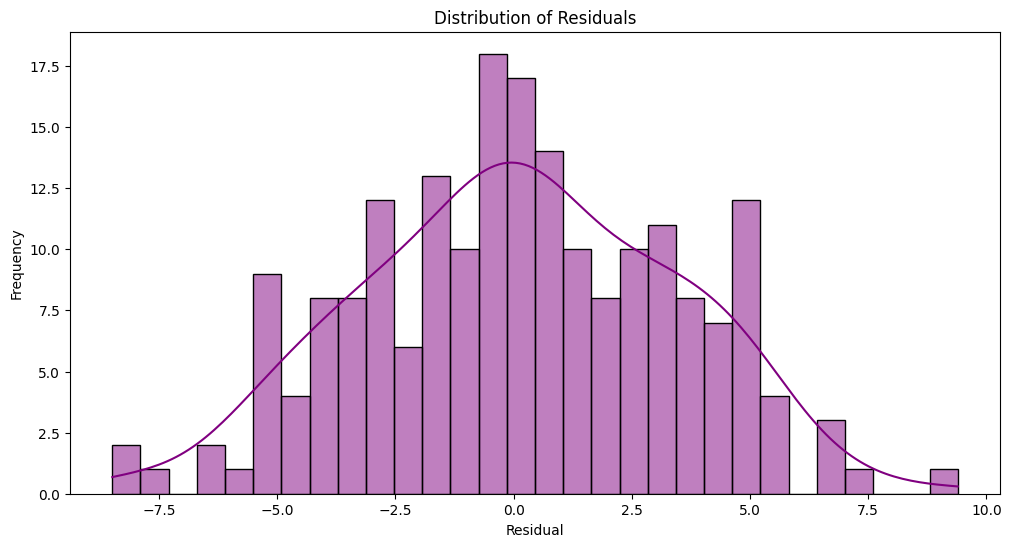

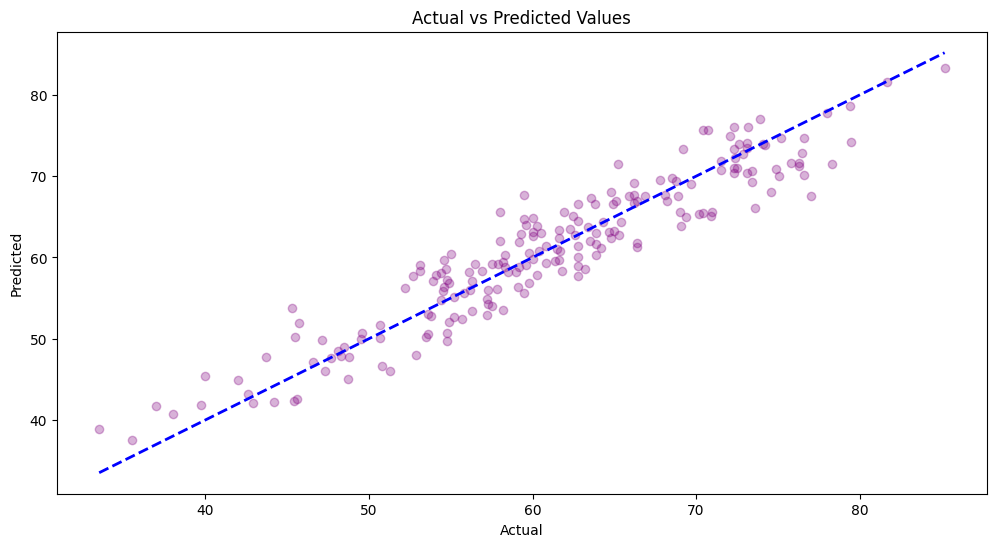

In [17]:
 # Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True, bins=30, color = 'purple')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color = 'purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--b', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.show()

## <b><div style='padding:15px;background-color:purple;color:white;border-radius:40px;font-size:110%;text-align: center'>If you liked it, please upvote. Thank you very much.</div></b>